In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import (
    WeightedRandomSampler,
    DataLoader,
    Subset
)
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from src.models import *
from src.data import *
from src.train import *

from src.augmentations import (
    augmentation_list,
    augmentation_count,
    eval_transform
)

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DEVICE")
print("=" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
train_path = "E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/dataset/CROP+MERGED/train"
train_path_without_neysan="E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/dataset/CROP+MERGED - Copy/train"

In [5]:
set_seed(42)

train_loader, val_loader = create_train_val_loaders(
    train_path=train_path,
    train_transform=eval_transform,
    test_transform=eval_transform,
    batch_size=32
)

In [6]:
set_seed(42)

model = create_custom_cnn(
    num_classes=8
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

(
    best_val_accuracy,
    best_train_loss,
    best_train_accuracy,
    best_model_state,
    history
) = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=500,
    patience=75
)

torch.save(
    best_model_state,
    "cnn_best.pth"
)

print("\nBest CNN model:")

print(
    f"Best Train Loss: "
    f"{best_train_loss:.4f}"
)

print(
    f"Train Accuracy at Best Val: "
    f"{best_train_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print("Saved as: cnn_best.pth")


Epoch [1/500], Train Loss: 1.3714, Val Loss: 0.8939, Train Accuracy: 51.71%, Val Accuracy: 68.69%
Epoch [2/500], Train Loss: 0.7746, Val Loss: 0.6008, Train Accuracy: 72.60%, Val Accuracy: 79.46%
Epoch [3/500], Train Loss: 0.5712, Val Loss: 0.5936, Train Accuracy: 81.02%, Val Accuracy: 80.58%
Epoch [4/500], Train Loss: 0.4554, Val Loss: 0.5293, Train Accuracy: 84.76%, Val Accuracy: 83.73%
Epoch [5/500], Train Loss: 0.3193, Val Loss: 0.4102, Train Accuracy: 89.28%, Val Accuracy: 86.76%
Epoch [6/500], Train Loss: 0.2650, Val Loss: 0.3901, Train Accuracy: 90.82%, Val Accuracy: 86.98%
Epoch [7/500], Train Loss: 0.1939, Val Loss: 0.4086, Train Accuracy: 93.29%, Val Accuracy: 87.09%
Epoch [8/500], Train Loss: 0.1632, Val Loss: 0.3737, Train Accuracy: 94.39%, Val Accuracy: 88.89%
Epoch [9/500], Train Loss: 0.1111, Val Loss: 0.3091, Train Accuracy: 96.77%, Val Accuracy: 89.67%
Epoch [10/500], Train Loss: 0.1157, Val Loss: 0.4201, Train Accuracy: 96.29%, Val Accuracy: 85.86%
Epoch [11/500], Tra

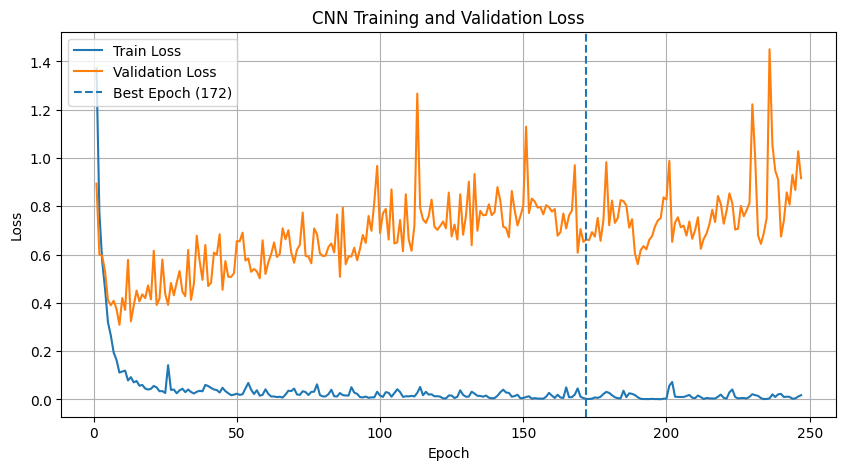

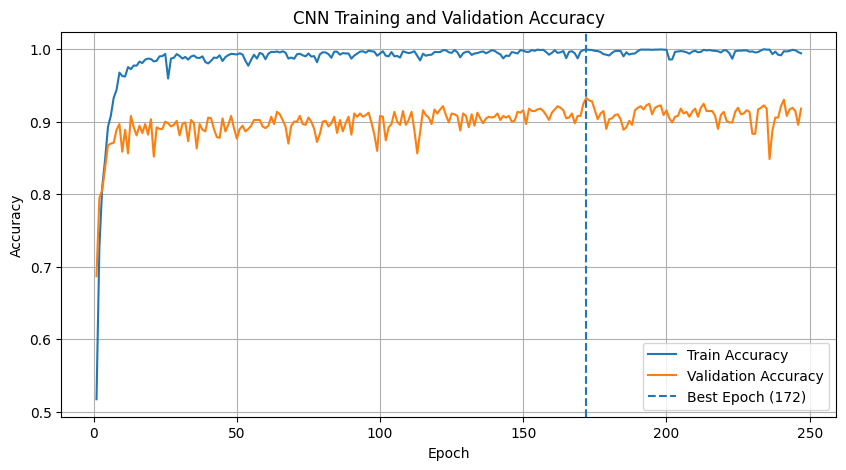

In [8]:
epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

best_epoch = (
    np.argmax(history["val_accuracy"]) + 1
)


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()


In [9]:
set_seed(42)

train_loader, val_loader = create_train_val_loaders_balanced(
    train_path=train_path,
    train_transform=eval_transform,
    test_transform=eval_transform,
    batch_size=32
)

model = create_custom_cnn(
    num_classes=8
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

(
    best_val_accuracy,
    best_train_loss,
    best_train_accuracy,
    best_model_state,
    history
) = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=500,
    patience=75
)

torch.save(
    best_model_state,
    "cnn_balanced_best.pth"
)

print("\nBest Balanced CNN model:")

print(
    f"Best Train Loss: "
    f"{best_train_loss:.4f}"
)

print(
    f"Train Accuracy at Best Val: "
    f"{best_train_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print("Saved as: cnn_balanced_best.pth")

Epoch [1/500], Train Loss: 1.2128, Val Loss: 0.7929, Train Accuracy: 57.52%, Val Accuracy: 73.74%
Epoch [2/500], Train Loss: 0.6724, Val Loss: 0.5334, Train Accuracy: 77.42%, Val Accuracy: 82.49%
Epoch [3/500], Train Loss: 0.4405, Val Loss: 0.4400, Train Accuracy: 85.28%, Val Accuracy: 85.30%
Epoch [4/500], Train Loss: 0.3231, Val Loss: 0.4598, Train Accuracy: 88.43%, Val Accuracy: 83.84%
Epoch [5/500], Train Loss: 0.2235, Val Loss: 0.4089, Train Accuracy: 92.26%, Val Accuracy: 86.20%
Epoch [6/500], Train Loss: 0.1802, Val Loss: 0.4782, Train Accuracy: 93.89%, Val Accuracy: 83.28%
Epoch [7/500], Train Loss: 0.1360, Val Loss: 0.5637, Train Accuracy: 95.55%, Val Accuracy: 83.05%
Epoch [8/500], Train Loss: 0.0998, Val Loss: 0.4995, Train Accuracy: 97.02%, Val Accuracy: 87.21%
Epoch [9/500], Train Loss: 0.1178, Val Loss: 0.4081, Train Accuracy: 96.09%, Val Accuracy: 87.77%
Epoch [10/500], Train Loss: 0.0886, Val Loss: 0.3666, Train Accuracy: 97.21%, Val Accuracy: 89.11%
Epoch [11/500], Tra

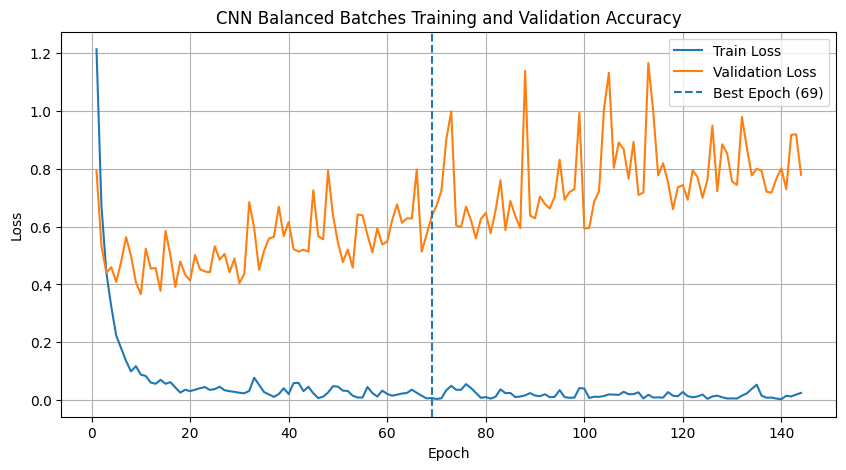

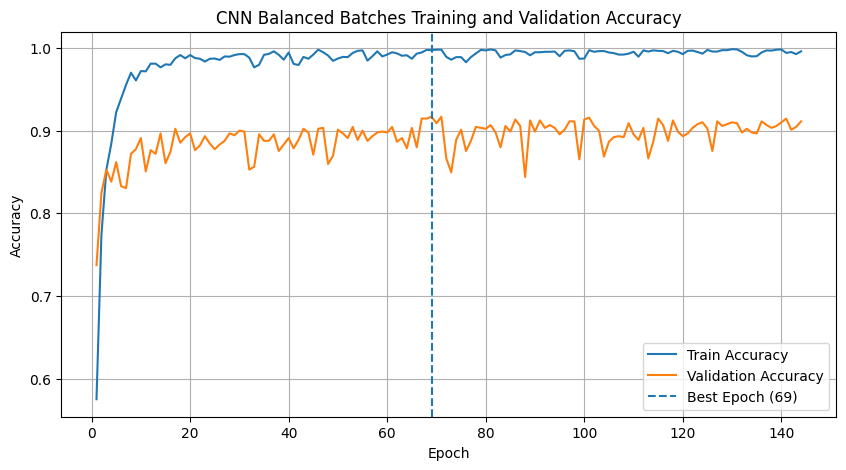

In [ ]:
epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

best_epoch = (
    np.argmax(history["val_accuracy"]) + 1
)


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Balanced Batches Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Balanced Batches Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [13]:
set_seed(42)

model = create_custom_cnn(
    num_classes=8
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

(
    best_val_accuracy,
    best_train_loss,
    best_train_accuracy,
    best_model_state,
    history
) = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=500,
    patience=75
)

torch.save(
    best_model_state,
    "cnn_wd_1e-4.pth"
)

print("\nCNN - Weight Decay = 1e-4:")

print(
    f"Best Train Loss: "
    f"{best_train_loss:.4f}"
)

print(
    f"Train Accuracy at Best Val: "
    f"{best_train_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print("Saved as: cnn_wd_1e-4.pth")

Epoch [1/500], Train Loss: 1.2320, Val Loss: 0.7716, Train Accuracy: 56.64%, Val Accuracy: 73.74%
Epoch [2/500], Train Loss: 0.6717, Val Loss: 0.5639, Train Accuracy: 77.39%, Val Accuracy: 81.59%
Epoch [3/500], Train Loss: 0.4496, Val Loss: 0.4270, Train Accuracy: 84.63%, Val Accuracy: 86.20%
Epoch [4/500], Train Loss: 0.3096, Val Loss: 0.4908, Train Accuracy: 88.96%, Val Accuracy: 83.73%
Epoch [5/500], Train Loss: 0.2216, Val Loss: 0.5348, Train Accuracy: 92.57%, Val Accuracy: 82.94%
Epoch [6/500], Train Loss: 0.1660, Val Loss: 0.5651, Train Accuracy: 94.68%, Val Accuracy: 82.38%
Epoch [7/500], Train Loss: 0.1445, Val Loss: 0.3713, Train Accuracy: 94.99%, Val Accuracy: 87.43%
Epoch [8/500], Train Loss: 0.0982, Val Loss: 0.5236, Train Accuracy: 96.93%, Val Accuracy: 86.20%
Epoch [9/500], Train Loss: 0.0809, Val Loss: 0.5675, Train Accuracy: 97.30%, Val Accuracy: 83.84%
Epoch [10/500], Train Loss: 0.0835, Val Loss: 0.3683, Train Accuracy: 97.41%, Val Accuracy: 89.11%
Epoch [11/500], Tra

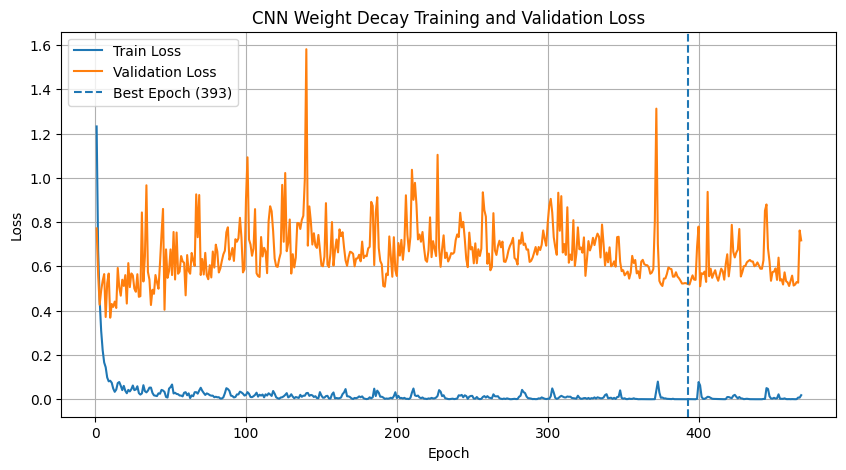

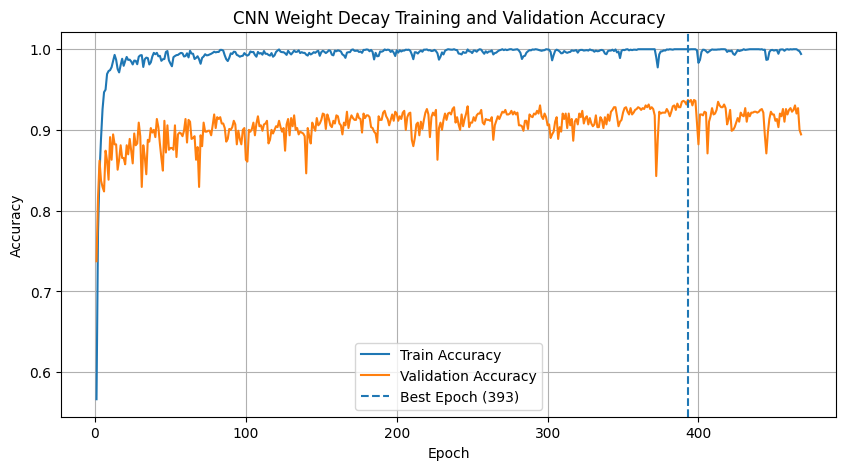

In [15]:
epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

best_epoch = (
    np.argmax(history["val_accuracy"]) + 1
)


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Weight Decay Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Weight Decay Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [6]:
set_seed(42)

model = create_custom_cnn(
    num_classes=8
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

(
    best_val_accuracy,
    best_train_loss,
    best_train_accuracy,
    best_model_state,
    history
) = train_model_weight_scheduler(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=500,
    patience=75
)

torch.save(
    best_model_state,
    "cnn_d2_scheduler.pth"
)

print("\nCNN - Learning Rate Scheduler:")

print(
    f"Best Train Loss: "
    f"{best_train_loss:.4f}"
)

print(
    f"Train Accuracy at Best Val: "
    f"{best_train_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print("Saved as: cnn_scheduler.pth")

Epoch [1/500], Train Loss: 1.3714, Val Loss: 0.8939, Train Accuracy: 51.71%, Val Accuracy: 68.69%, LR: 0.000100
Epoch [2/500], Train Loss: 0.7746, Val Loss: 0.6008, Train Accuracy: 72.60%, Val Accuracy: 79.46%, LR: 0.000100
Epoch [3/500], Train Loss: 0.5712, Val Loss: 0.5936, Train Accuracy: 81.02%, Val Accuracy: 80.58%, LR: 0.000100
Epoch [4/500], Train Loss: 0.4554, Val Loss: 0.5293, Train Accuracy: 84.76%, Val Accuracy: 83.73%, LR: 0.000100
Epoch [5/500], Train Loss: 0.3193, Val Loss: 0.4102, Train Accuracy: 89.28%, Val Accuracy: 86.76%, LR: 0.000100
Epoch [6/500], Train Loss: 0.2650, Val Loss: 0.3901, Train Accuracy: 90.82%, Val Accuracy: 86.98%, LR: 0.000100
Epoch [7/500], Train Loss: 0.1939, Val Loss: 0.4086, Train Accuracy: 93.29%, Val Accuracy: 87.09%, LR: 0.000100
Epoch [8/500], Train Loss: 0.1632, Val Loss: 0.3737, Train Accuracy: 94.39%, Val Accuracy: 88.89%, LR: 0.000100
Epoch [9/500], Train Loss: 0.1111, Val Loss: 0.3091, Train Accuracy: 96.77%, Val Accuracy: 89.67%, LR: 0

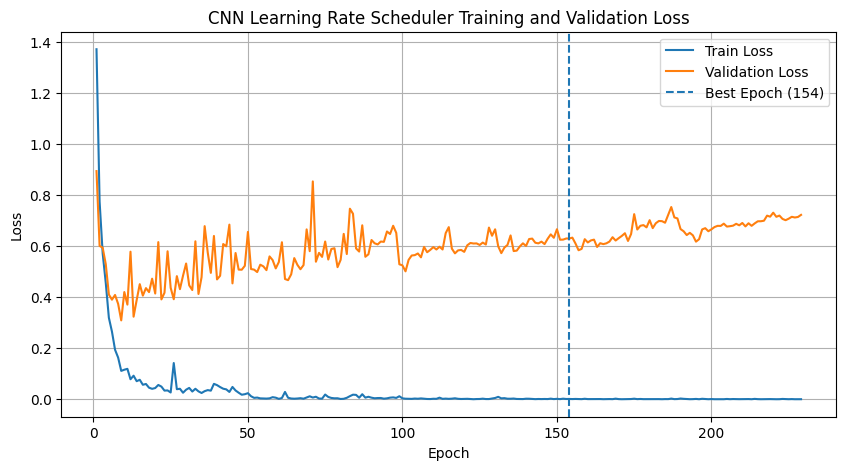

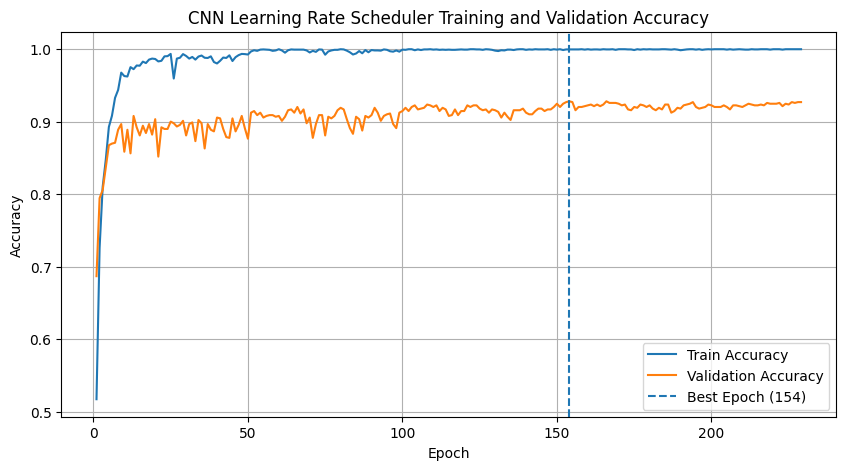

In [7]:
epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

best_epoch = (
    np.argmax(history["val_accuracy"]) + 1
)


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Learning Rate Scheduler Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Learning Rate Scheduler Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [8]:
class BCEWithLogitsLossOneHot(nn.Module):

    def __init__(self, num_classes=8):
        super().__init__()

        self.num_classes = num_classes

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, outputs, labels):

        labels_one_hot = torch.zeros(
            labels.size(0),
            self.num_classes,
            device=labels.device
        )

        labels_one_hot.scatter_(
            1,
            labels.unsqueeze(1),
            1.0
        )

        return self.bce(
            outputs,
            labels_one_hot
        )

Epoch [1/200], Train Loss: 3.3650, Val Loss: 2.0029, Train Accuracy: 16.65%, Val Accuracy: 24.35%, LR: 0.001000
Epoch [2/200], Train Loss: 2.0313, Val Loss: 2.0004, Train Accuracy: 16.34%, Val Accuracy: 23.01%, LR: 0.001000
Epoch [3/200], Train Loss: 2.0111, Val Loss: 1.9737, Train Accuracy: 18.78%, Val Accuracy: 25.36%, LR: 0.001000
Epoch [4/200], Train Loss: 1.9980, Val Loss: 1.8713, Train Accuracy: 20.16%, Val Accuracy: 27.50%, LR: 0.001000
Epoch [5/200], Train Loss: 1.9477, Val Loss: 1.8240, Train Accuracy: 22.04%, Val Accuracy: 31.31%, LR: 0.001000
Epoch [6/200], Train Loss: 1.9284, Val Loss: 1.8522, Train Accuracy: 22.88%, Val Accuracy: 30.19%, LR: 0.001000
Epoch [7/200], Train Loss: 1.9130, Val Loss: 1.7697, Train Accuracy: 23.36%, Val Accuracy: 29.07%, LR: 0.001000
Epoch [8/200], Train Loss: 1.9088, Val Loss: 1.6932, Train Accuracy: 25.01%, Val Accuracy: 39.06%, LR: 0.001000
Epoch [9/200], Train Loss: 1.8632, Val Loss: 1.7156, Train Accuracy: 25.86%, Val Accuracy: 40.74%, LR: 0

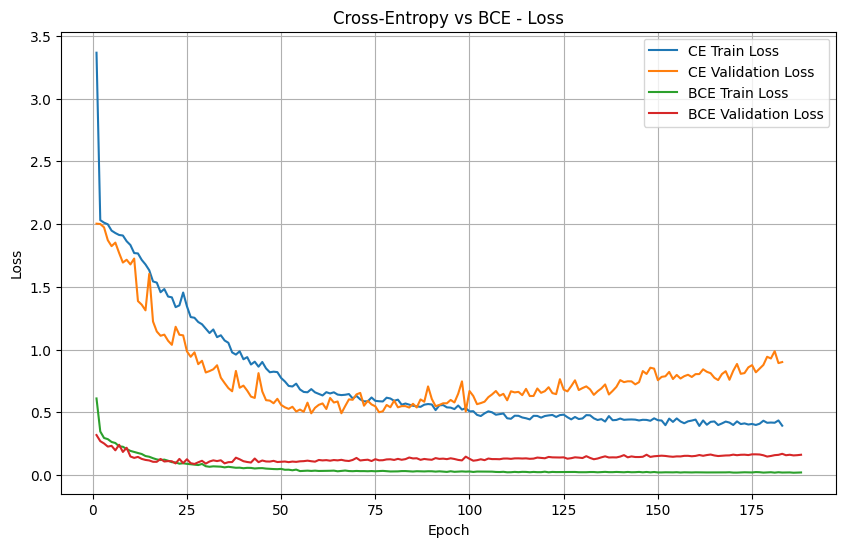

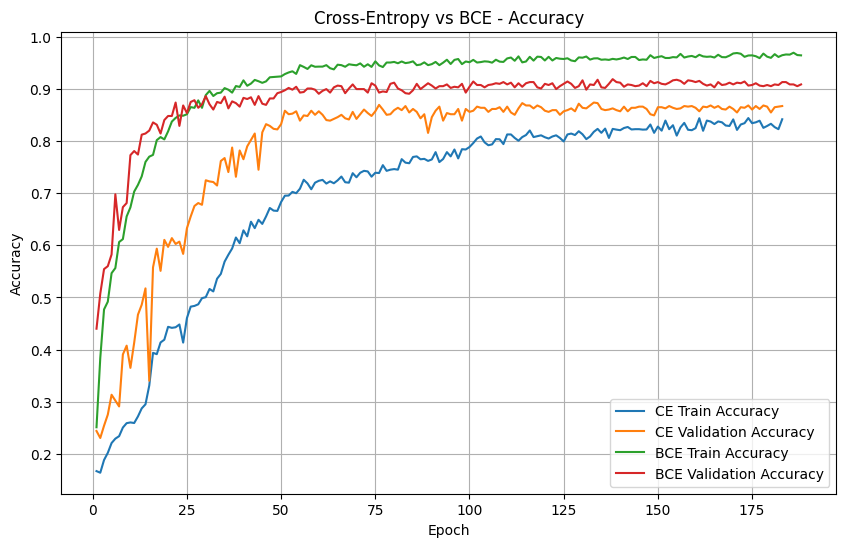

In [11]:
set_seed(42)

model_ce = create_custom_cnn(
    num_classes=8
)

optimizer_ce = torch.optim.Adam(
    model_ce.parameters(),
    lr=0.001
)

scheduler_ce = torch.optim.lr_scheduler.StepLR(
    optimizer_ce,
    step_size=50,
    gamma=0.5
)

criterion_ce = nn.CrossEntropyLoss()


(
    best_val_accuracy_ce,
    best_train_loss_ce,
    best_train_accuracy_ce,
    best_model_state_ce,
    history_ce
) = train_model_weight_scheduler(
    model=model_ce,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_ce,
    scheduler=scheduler_ce,
    epochs=200,
    patience=50,
    criterion=criterion_ce
)


torch.save(
    best_model_state_ce,
    "cnn_cross_entropy_scheduler.pth"
)


set_seed(42)

model_bce = create_custom_cnn(
    num_classes=8
)

optimizer_bce = torch.optim.Adam(
    model_bce.parameters(),
    lr=0.001
)

scheduler_bce = torch.optim.lr_scheduler.StepLR(
    optimizer_bce,
    step_size=50,
    gamma=0.5
)

criterion_bce = BCEWithLogitsLossOneHot(
    num_classes=8
)


(
    best_val_accuracy_bce,
    best_train_loss_bce,
    best_train_accuracy_bce,
    best_model_state_bce,
    history_bce
) = train_model_weight_scheduler(
    model=model_bce,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_bce,
    scheduler=scheduler_bce,
    epochs=200,
    patience=50,
    criterion=criterion_bce
)


torch.save(
    best_model_state_bce,
    "cnn_bce_scheduler.pth"
)


print("\n" + "=" * 60)
print("Cross-Entropy vs BCE")
print("=" * 60)

print(
    f"Cross-Entropy Best Validation Accuracy: "
    f"{best_val_accuracy_ce * 100:.2f}%"
)

print(
    f"BCE Best Validation Accuracy: "
    f"{best_val_accuracy_bce * 100:.2f}%"
)

print(
    f"\nCross-Entropy Best Train Loss: "
    f"{best_train_loss_ce:.4f}"
)

print(
    f"BCE Best Train Loss: "
    f"{best_train_loss_bce:.4f}"
)


epochs_ce = range(
    1,
    len(history_ce["train_loss"]) + 1
)

epochs_bce = range(
    1,
    len(history_bce["train_loss"]) + 1
)


plt.figure(figsize=(10, 6))

plt.plot(
    epochs_ce,
    history_ce["train_loss"],
    label="CE Train Loss"
)

plt.plot(
    epochs_ce,
    history_ce["val_loss"],
    label="CE Validation Loss"
)

plt.plot(
    epochs_bce,
    history_bce["train_loss"],
    label="BCE Train Loss"
)

plt.plot(
    epochs_bce,
    history_bce["val_loss"],
    label="BCE Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy vs BCE - Loss")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    epochs_ce,
    history_ce["train_accuracy"],
    label="CE Train Accuracy"
)

plt.plot(
    epochs_ce,
    history_ce["val_accuracy"],
    label="CE Validation Accuracy"
)

plt.plot(
    epochs_bce,
    history_bce["train_accuracy"],
    label="BCE Train Accuracy"
)

plt.plot(
    epochs_bce,
    history_bce["val_accuracy"],
    label="BCE Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Cross-Entropy vs BCE - Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 150, 150])
Labels shape: torch.Size([32])


In [13]:
class BCELossForMultiClass(nn.Module):

    def __init__(self):
        super().__init__()

        self.loss = nn.BCEWithLogitsLoss()

    def forward(self, outputs, labels):

        labels = torch.nn.functional.one_hot(
            labels,
            num_classes=outputs.size(1)
        ).float()

        return self.loss(
            outputs,
            labels
        )

In [17]:
comparison_rows = []

for experiment_name, result in experiment_results.items():

    comparison_rows.append({

        "Experiment":
            experiment_name,

        "Macro Precision":
            result["macro_precision"],

        "Macro Recall":
            result["macro_recall"],

        "Macro F1":
            result["macro_f1"],

        "Lowest-Recall Class":
            result["lowest_recall_class"],

        "Lowest-Precision Class":
            result["lowest_precision_class"]
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df

,Experiment,Macro Precision,Macro Recall,Macro F1,Lowest-Recall Class,Lowest-Precision Class
0,CNN baseline,0.895004,0.893697,0.893133,kamyun,kamyunet
1,Balanced batches,0.609764,0.576747,0.528900,savari,taxi
2,CrossEntropy / BCE comparison,0.938228,0.933464,0.933322,kamyun,kamyunet
3,Best regularized + scheduled model,0.951048,0.951391,0.950654,kamyun,kamyunet


In [18]:
comparison_df.style.format({
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}"
})

,Experiment,Macro Precision,Macro Recall,Macro F1,Lowest-Recall Class,Lowest-Precision Class
0,CNN baseline,0.8950,0.8937,0.8931,kamyun,kamyunet
1,Balanced batches,0.6098,0.5767,0.5289,savari,taxi
2,CrossEntropy / BCE comparison,0.9382,0.9335,0.9333,kamyun,kamyunet
3,Best regularized + scheduled model,0.9510,0.9514,0.9507,kamyun,kamyunet


In [ ]:
seeds = [42, 10, 20]

layer4_results = []


for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Model: ResNet18 Layer4")
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)

        set_seed(seed)

        train_loader, val_loader = create_train_val_loaders(
            train_path=train_path,
            train_transform=train_transform,
            test_transform=eval_transform,
            batch_size=32
        )

        model = create_resnet18_layer4(
            num_classes=8
        )

        optimizer = torch.optim.Adam([
            {
                "params": model.layer4.parameters(),
                "lr": 0.0001
            },
            {
                "params": model.fc.parameters(),
                "lr": 0.001
            }
        ])

        (
            best_val_accuracy,
            best_train_loss,
            best_train_accuracy,
            best_model_state
        ) = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            epochs=500,
            patience=75
        )

        layer4_results.append({
            "model": "ResNet18 Layer4",
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count":
                augmentation_count[augmentation_name],
            "model_state": best_model_state
        })

        print(
            f"Best Train Loss: "
            f"{best_train_loss:.4f}"
        )

        print(
            f"Train Accuracy at Best Val: "
            f"{best_train_accuracy * 100:.2f}%"
        )

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


best_layer4 = layer4_results[0]


for result in layer4_results:

    if (
        result["best_val_accuracy"]
        > best_layer4["best_val_accuracy"]
    ):

        best_layer4 = result

    elif (
        result["best_val_accuracy"]
        == best_layer4["best_val_accuracy"]
        and
        result["augmentation_count"]
        > best_layer4["augmentation_count"]
    ):

        best_layer4 = result


torch.save(
    best_layer4["model_state"],
    "resnet18_layer4_best.pth"
)


print("\nBest ResNet18 Layer4 model:")

print(
    f"Augmentation: "
    f"{best_layer4['augmentation']}"
)

print(
    f"Seed: "
    f"{best_layer4['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_layer4['best_val_accuracy'] * 100:.2f}%"
)

print("Saved as: resnet18_d2_layer4_best.pth")


Model: ResNet18 Layer4
Augmentation: No Augmentation
Seed: 42
Epoch [1/500], Train Loss: 0.6135, Train Accuracy: 79.23%, Val Accuracy: 91.25%
Epoch [2/500], Train Loss: 0.0973, Train Accuracy: 97.42%, Val Accuracy: 93.15%
Epoch [3/500], Train Loss: 0.0251, Train Accuracy: 99.58%, Val Accuracy: 93.60%
Epoch [4/500], Train Loss: 0.0102, Train Accuracy: 99.89%, Val Accuracy: 94.28%
Epoch [5/500], Train Loss: 0.0055, Train Accuracy: 99.94%, Val Accuracy: 94.61%
Epoch [6/500], Train Loss: 0.0033, Train Accuracy: 100.00%, Val Accuracy: 94.16%
Epoch [7/500], Train Loss: 0.0035, Train Accuracy: 99.97%, Val Accuracy: 94.05%
Epoch [8/500], Train Loss: 0.0030, Train Accuracy: 99.94%, Val Accuracy: 94.16%
Epoch [9/500], Train Loss: 0.0041, Train Accuracy: 99.94%, Val Accuracy: 94.39%
Epoch [10/500], Train Loss: 0.0015, Train Accuracy: 100.00%, Val Accuracy: 94.28%
Epoch [11/500], Train Loss: 0.0086, Train Accuracy: 99.72%, Val Accuracy: 93.27%
Epoch [12/500], Train Loss: 0.0134, Train Accuracy: 9

In [ ]:
seeds = [42, 10, 20]

full_results = []


for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Model: ResNet18 Full")
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)

        set_seed(seed)

        train_loader, val_loader = create_train_val_loaders(
            train_path=train_path,
            train_transform=train_transform,
            test_transform=eval_transform,
            batch_size=32
        )

        model = create_resnet18_full(
            num_classes=8
        )

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0001
        )

        (
            best_val_accuracy,
            best_train_loss,
            best_train_accuracy,
            best_model_state
        ) = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            epochs=500,
            patience=50
        )

        full_results.append({
            "model": "ResNet18 Full",
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count":
                augmentation_count[augmentation_name],
            "model_state": best_model_state
        })

        print(
            f"Best Train Loss: "
            f"{best_train_loss:.4f}"
        )

        print(
            f"Train Accuracy at Best Val: "
            f"{best_train_accuracy * 100:.2f}%"
        )

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


best_full = full_results[0]


for result in full_results:

    if (
        result["best_val_accuracy"]
        > best_full["best_val_accuracy"]
    ):

        best_full = result

    elif (
        result["best_val_accuracy"]
        == best_full["best_val_accuracy"]
        and
        result["augmentation_count"]
        > best_full["augmentation_count"]
    ):

        best_full = result


torch.save(
    best_full["model_state"],
    "resnet18_full_best.pth"
)


print("\nBest ResNet18 Full model:")

print(
    f"Augmentation: "
    f"{best_full['augmentation']}"
)

print(
    f"Seed: "
    f"{best_full['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_full['best_val_accuracy'] * 100:.2f}%"
)

print("Saved as: resnet18_d2_full_best.pth")


Model: ResNet18 Full
Augmentation: No Augmentation
Seed: 42
Epoch [1/500], Train Loss: 0.5415, Train Accuracy: 82.54%, Val Accuracy: 93.60%
Epoch [2/500], Train Loss: 0.0682, Train Accuracy: 98.43%, Val Accuracy: 94.84%
Epoch [3/500], Train Loss: 0.0190, Train Accuracy: 99.83%, Val Accuracy: 95.74%
Epoch [4/500], Train Loss: 0.0096, Train Accuracy: 99.86%, Val Accuracy: 95.96%
Epoch [5/500], Train Loss: 0.0045, Train Accuracy: 100.00%, Val Accuracy: 95.74%
Epoch [6/500], Train Loss: 0.0033, Train Accuracy: 99.97%, Val Accuracy: 95.96%
Epoch [7/500], Train Loss: 0.0104, Train Accuracy: 99.78%, Val Accuracy: 94.73%
Epoch [8/500], Train Loss: 0.0112, Train Accuracy: 99.66%, Val Accuracy: 94.84%
Epoch [9/500], Train Loss: 0.0215, Train Accuracy: 99.30%, Val Accuracy: 91.69%
Epoch [10/500], Train Loss: 0.0447, Train Accuracy: 98.57%, Val Accuracy: 94.50%
Epoch [11/500], Train Loss: 0.0179, Train Accuracy: 99.49%, Val Accuracy: 96.63%
Epoch [12/500], Train Loss: 0.0072, Train Accuracy: 99.8

In [ ]:
seeds = [42, 10, 20]

full_results = []


for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Model: ResNet18 Full")
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)

        set_seed(seed)

        train_loader, val_loader = create_train_val_loaders(
            train_path=train_path,
            train_transform=train_transform,
            test_transform=eval_transform,
            batch_size=32
        )

        model = create_resnet18_full(
            num_classes=8
        )

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0001
        )

        (
            best_val_accuracy,
            best_train_loss,
            best_train_accuracy,
            best_model_state
        ) = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            epochs=500,
            patience=75
        )

        full_results.append({
            "model": "ResNet18 Full",
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count":
                augmentation_count[augmentation_name],
            "model_state": best_model_state
        })

        print(
            f"Best Train Loss: "
            f"{best_train_loss:.4f}"
        )

        print(
            f"Train Accuracy at Best Val: "
            f"{best_train_accuracy * 100:.2f}%"
        )

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


best_full = full_results[0]


for result in full_results:

    if (
        result["best_val_accuracy"]
        > best_full["best_val_accuracy"]
    ):

        best_full = result

    elif (
        result["best_val_accuracy"]
        == best_full["best_val_accuracy"]
        and
        result["augmentation_count"]
        > best_full["augmentation_count"]
    ):

        best_full = result


torch.save(
    best_full["model_state"],
    "resnet18_full_best.pth"
)


print("\nBest ResNet18 Full model:")

print(
    f"Augmentation: "
    f"{best_full['augmentation']}"
)

print(
    f"Seed: "
    f"{best_full['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_full['best_val_accuracy'] * 100:.2f}%"
)

print("Saved as: resnet18_d2_full_best.pth")


Model: ResNet18 Full
Augmentation: No Augmentation
Seed: 42
Epoch [1/500], Train Loss: 0.5418, Train Accuracy: 82.59%, Val Accuracy: 93.04%
Epoch [2/500], Train Loss: 0.0670, Train Accuracy: 98.34%, Val Accuracy: 94.95%
Epoch [3/500], Train Loss: 0.0190, Train Accuracy: 99.78%, Val Accuracy: 95.85%
Epoch [4/500], Train Loss: 0.0091, Train Accuracy: 99.94%, Val Accuracy: 95.74%
Epoch [5/500], Train Loss: 0.0045, Train Accuracy: 100.00%, Val Accuracy: 95.85%
Epoch [6/500], Train Loss: 0.0033, Train Accuracy: 99.97%, Val Accuracy: 96.07%
Epoch [7/500], Train Loss: 0.0111, Train Accuracy: 99.72%, Val Accuracy: 94.73%
Epoch [8/500], Train Loss: 0.0105, Train Accuracy: 99.72%, Val Accuracy: 94.61%
Epoch [9/500], Train Loss: 0.0175, Train Accuracy: 99.75%, Val Accuracy: 93.49%
Epoch [10/500], Train Loss: 0.0412, Train Accuracy: 98.74%, Val Accuracy: 87.21%
Epoch [11/500], Train Loss: 0.0255, Train Accuracy: 99.27%, Val Accuracy: 96.18%
Epoch [12/500], Train Loss: 0.0090, Train Accuracy: 99.8

In [ ]:
seeds = [42, 10, 20]

full_results = []


for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Model: ResNet18 Full")
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)

        set_seed(seed)

        train_loader, val_loader = create_train_val_loaders(
            train_path=train_path_without_neysan,
            train_transform=train_transform,
            test_transform=eval_transform,
            batch_size=32
        )

        model = create_resnet18_full(
            num_classes=8
        )

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0001
        )

        (
            best_val_accuracy,
            best_train_loss,
            best_train_accuracy,
            best_model_state
        ) = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            epochs=500,
            patience=75
        )

        full_results.append({
            "model": "ResNet18 Full",
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count":
                augmentation_count[augmentation_name],
            "model_state": best_model_state
        })

        print(
            f"Best Train Loss: "
            f"{best_train_loss:.4f}"
        )

        print(
            f"Train Accuracy at Best Val: "
            f"{best_train_accuracy * 100:.2f}%"
        )

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


best_full = full_results[0]


for result in full_results:

    if (
        result["best_val_accuracy"]
        > best_full["best_val_accuracy"]
    ):

        best_full = result

    elif (
        result["best_val_accuracy"]
        == best_full["best_val_accuracy"]
        and
        result["augmentation_count"]
        > best_full["augmentation_count"]
    ):

        best_full = result


torch.save(
    best_full["model_state"],
    "resnet18_d3_full_best.pth"
)


print("\nBest ResNet18 Full model:")

print(
    f"Augmentation: "
    f"{best_full['augmentation']}"
)

print(
    f"Seed: "
    f"{best_full['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_full['best_val_accuracy'] * 100:.2f}%"
)

print("Saved as: resnet18_withoutneysanclean_full_best.pth")


Model: ResNet18 Full
Augmentation: No Augmentation
Seed: 42
Epoch [1/500], Train Loss: 0.5528, Train Accuracy: 82.23%, Val Accuracy: 91.20%
Epoch [2/500], Train Loss: 0.0618, Train Accuracy: 99.04%, Val Accuracy: 94.92%
Epoch [3/500], Train Loss: 0.0194, Train Accuracy: 99.81%, Val Accuracy: 94.67%
Epoch [4/500], Train Loss: 0.0085, Train Accuracy: 99.97%, Val Accuracy: 94.80%
Epoch [5/500], Train Loss: 0.0048, Train Accuracy: 100.00%, Val Accuracy: 95.17%
Epoch [6/500], Train Loss: 0.0035, Train Accuracy: 99.97%, Val Accuracy: 94.80%
Epoch [7/500], Train Loss: 0.0041, Train Accuracy: 99.97%, Val Accuracy: 94.80%
Epoch [8/500], Train Loss: 0.0022, Train Accuracy: 100.00%, Val Accuracy: 94.80%
Epoch [9/500], Train Loss: 0.0020, Train Accuracy: 100.00%, Val Accuracy: 94.80%
Epoch [10/500], Train Loss: 0.0013, Train Accuracy: 100.00%, Val Accuracy: 94.67%
Epoch [11/500], Train Loss: 0.0012, Train Accuracy: 100.00%, Val Accuracy: 95.17%
Epoch [12/500], Train Loss: 0.0008, Train Accuracy: 

In [21]:
torch.save(
    best_full["model_state"],
    "resnet18_withoutneysanclean_full_best.pth"
)

In [ ]:
full_results_df = pd.DataFrame(full_results)

full_results_df = full_results_df[
    [
        "model",
        "augmentation",
        "seed",
        "best_val_accuracy",
        "augmentation_count"
    ]
]

full_results_df["best_val_accuracy"] *= 100



full_results_df

,model,augmentation,seed,best_val_accuracy,augmentation_count
0,ResNet18 Full,No Augmentation,42,96.778191,0
1,ResNet18 Full,No Augmentation,10,96.902107,0
2,ResNet18 Full,No Augmentation,20,97.149938,0
3,ResNet18 Full,Basic,42,96.902107,2
4,ResNet18 Full,Basic,10,96.902107,2
5,ResNet18 Full,Basic,20,97.645601,2
6,ResNet18 Full,Color,42,97.273854,1
7,ResNet18 Full,Color,10,97.149938,1
8,ResNet18 Full,Color,20,97.149938,1
9,ResNet18 Full,Crop,42,97.521685,1


In [19]:
full_results_df.to_csv(
    "resnet18_withoutneysanclean_full_best.csv",
    index=False
)

In [11]:
full_results_df = pd.DataFrame(full_results)

full_results_df = full_results_df[
    [
        "model",
        "augmentation",
        "seed",
        "best_val_accuracy",
        "augmentation_count"
    ]
]

full_results_df["best_val_accuracy"] *= 100

full_results_df.to_csv(
    "resnet18_full_results.csv",
    index=False
)

full_results_df

,model,augmentation,seed,best_val_accuracy,augmentation_count
0,ResNet18 Full,No Augmentation,42,97.867565,0
1,ResNet18 Full,No Augmentation,10,98.204265,0
2,ResNet18 Full,No Augmentation,20,97.418631,0
3,ResNet18 Full,Basic,42,97.867565,2
4,ResNet18 Full,Basic,10,97.867565,2
5,ResNet18 Full,Basic,20,97.643098,2
6,ResNet18 Full,Color,42,97.867565,1
7,ResNet18 Full,Color,10,97.643098,1
8,ResNet18 Full,Color,20,97.755331,1
9,ResNet18 Full,Crop,42,98.204265,1


In [13]:
results_df = pd.DataFrame(
    layer4_results + full_results
)

results_df = results_df[
    [
        "model",
        "augmentation",
        "seed",
        "best_val_accuracy"
    ]
]

results_df["best_val_accuracy"] *= 100

results_df = results_df.sort_values(
    "best_val_accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,model,augmentation,seed,best_val_accuracy
0,ResNet18 Full,Crop,42,98.204265
1,ResNet18 Full,No Augmentation,10,98.204265
2,ResNet18 Full,Full without Color,10,97.979798
3,ResNet18 Full,Basic,42,97.867565
4,ResNet18 Full,Basic,10,97.867565
5,ResNet18 Full,No Augmentation,42,97.867565
6,ResNet18 Full,Full without Color,42,97.867565
7,ResNet18 Full,Color,42,97.867565
8,ResNet18 Full,Full,10,97.867565
9,ResNet18 Full,Full without Color,20,97.867565


In [14]:
results_df.to_csv(
    "resnet18_results.csv",
    index=False
)